In [230]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
import matplotlib as mpl

rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

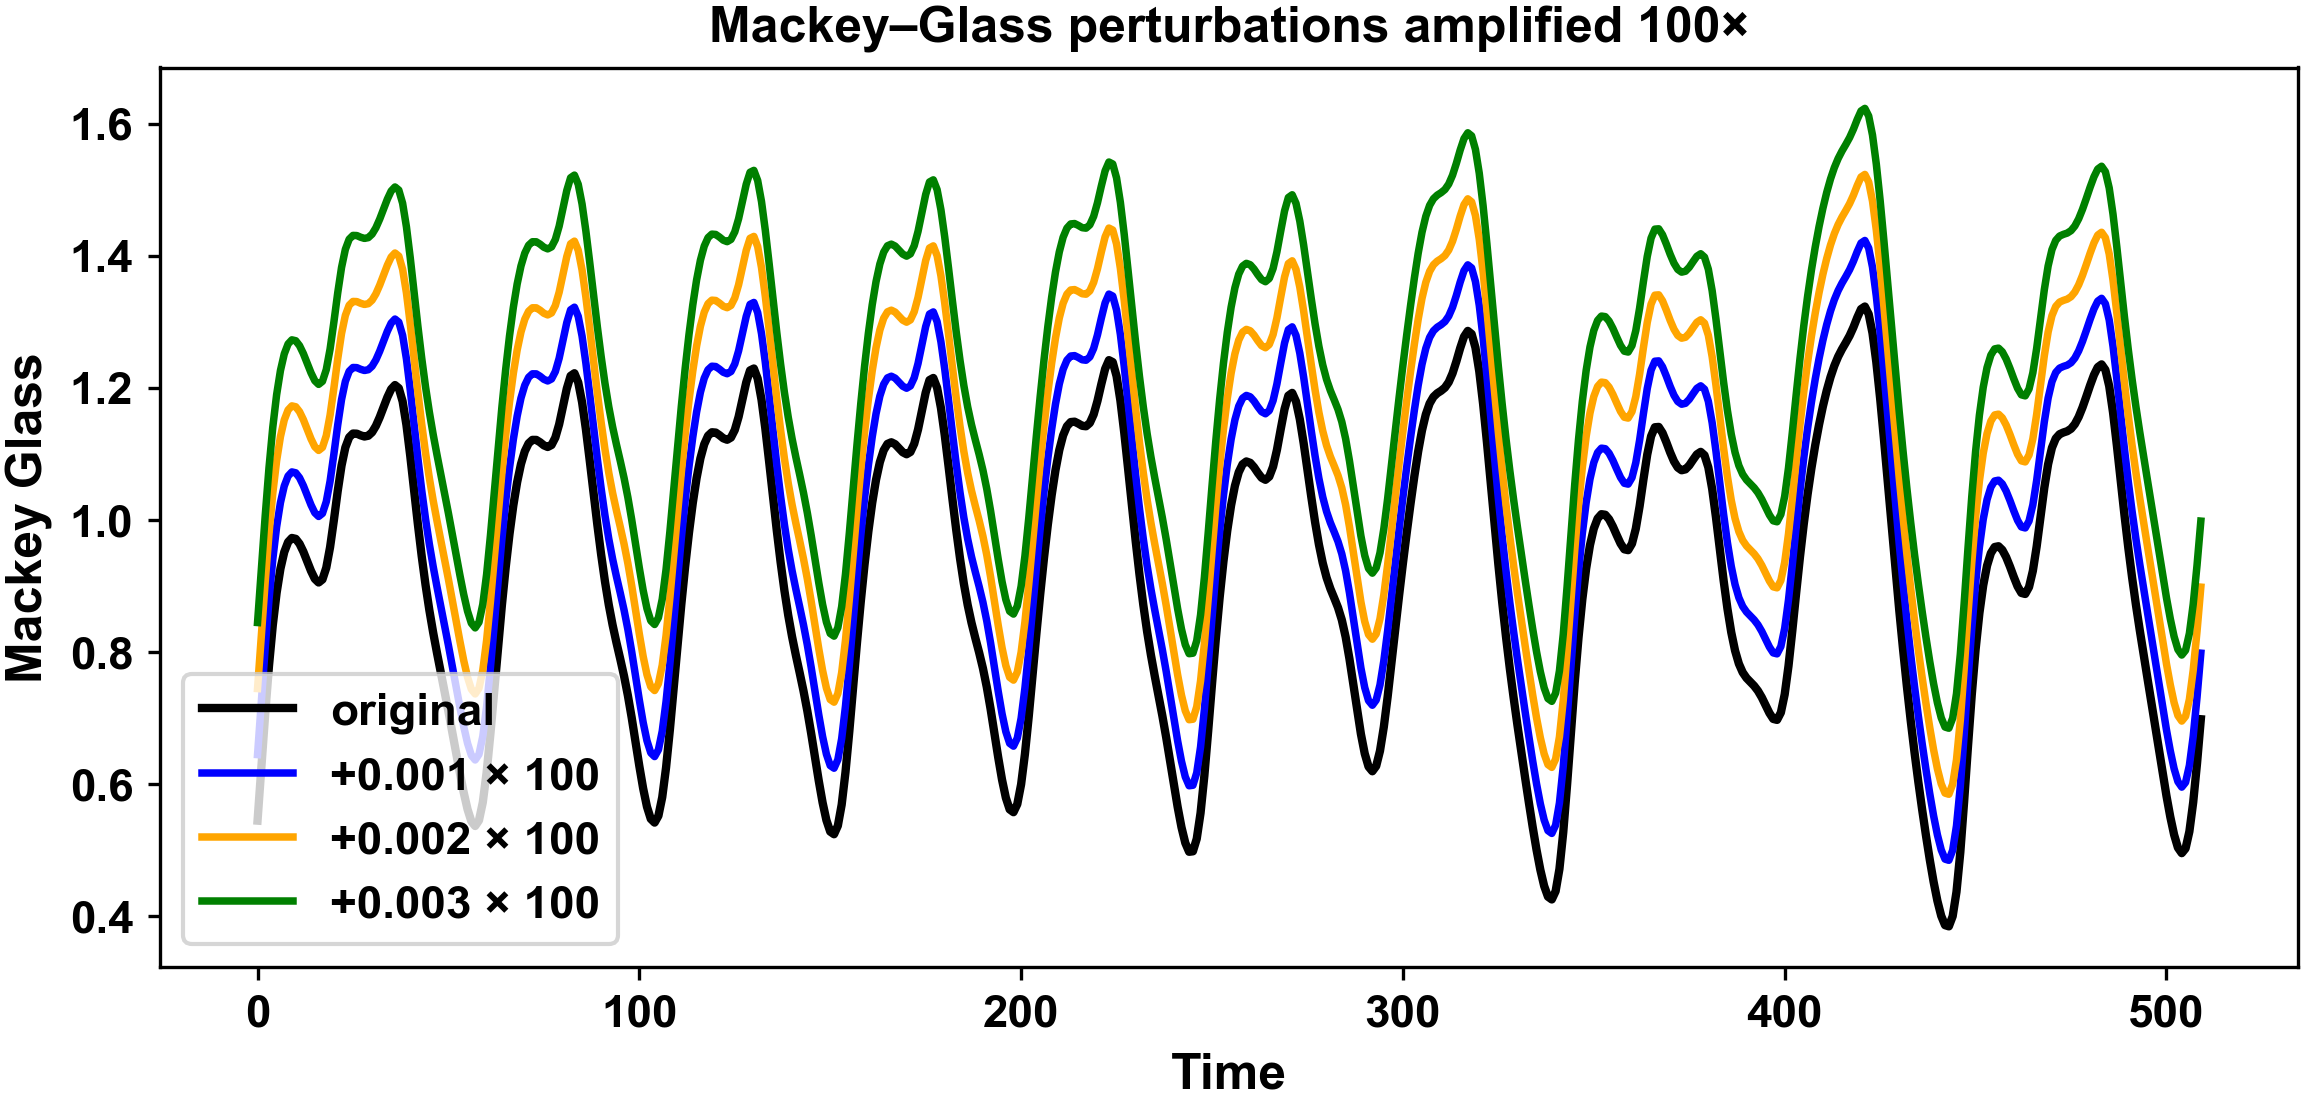

In [234]:
import numpy as np
import matplotlib.pyplot as plt

y0 = np.array(mackey_glass(Npoints=500))


ys = [np.asarray(y0),np.asarray(y0) + 0.001,np.asarray(y0) + 0.002,np.asarray(y0) + 0.003]

colors = ["purple", "blue", "orange", "green"]
labels = ["original", "+0.001", "+0.002", "+0.003"]

zoom_factor = 100

fig, ax = plt.subplots(figsize=(8, 4))

# Plot original trajectory
ax.plot(y0, color="black", linewidth=2, label="original")

# Plot visually magnified deviations
for y, c, lab in zip(ys[1:], colors[1:], labels[1:]):
    y_zoomed = y0 + zoom_factor * (y - y0)
    ax.plot(y_zoomed, color=c, linewidth=1.8, label=f"{lab} × {zoom_factor}")

ax.set_title("Mackey–Glass perturbations amplified 100×")
ax.set_xlabel("Time")
ax.set_ylabel("Mackey Glass")
ax.legend()

plt.tight_layout()
plt.savefig('mackeyglassallperturbed.png')
plt.show()

In [187]:
Nfading = 10
Ntraining = 290
Ntotal = 500
Ntesting = Ntotal - Nfading - Ntraining
tau= 1
K = Ntotal-tau

We observe the sepatation property. 

In [191]:
file_names = ['reservoir1.csv', 'allperturbed_001.csv', 'allperturbed_002.csv', 'allperturbed_003.csv']
y_output, X_observables = separation(file_names, Nfading = Nfading, Ntraining = Ntraining, Ntotal = Ntotal, tau =tau)
print('Done collecting data')

Done collecting data


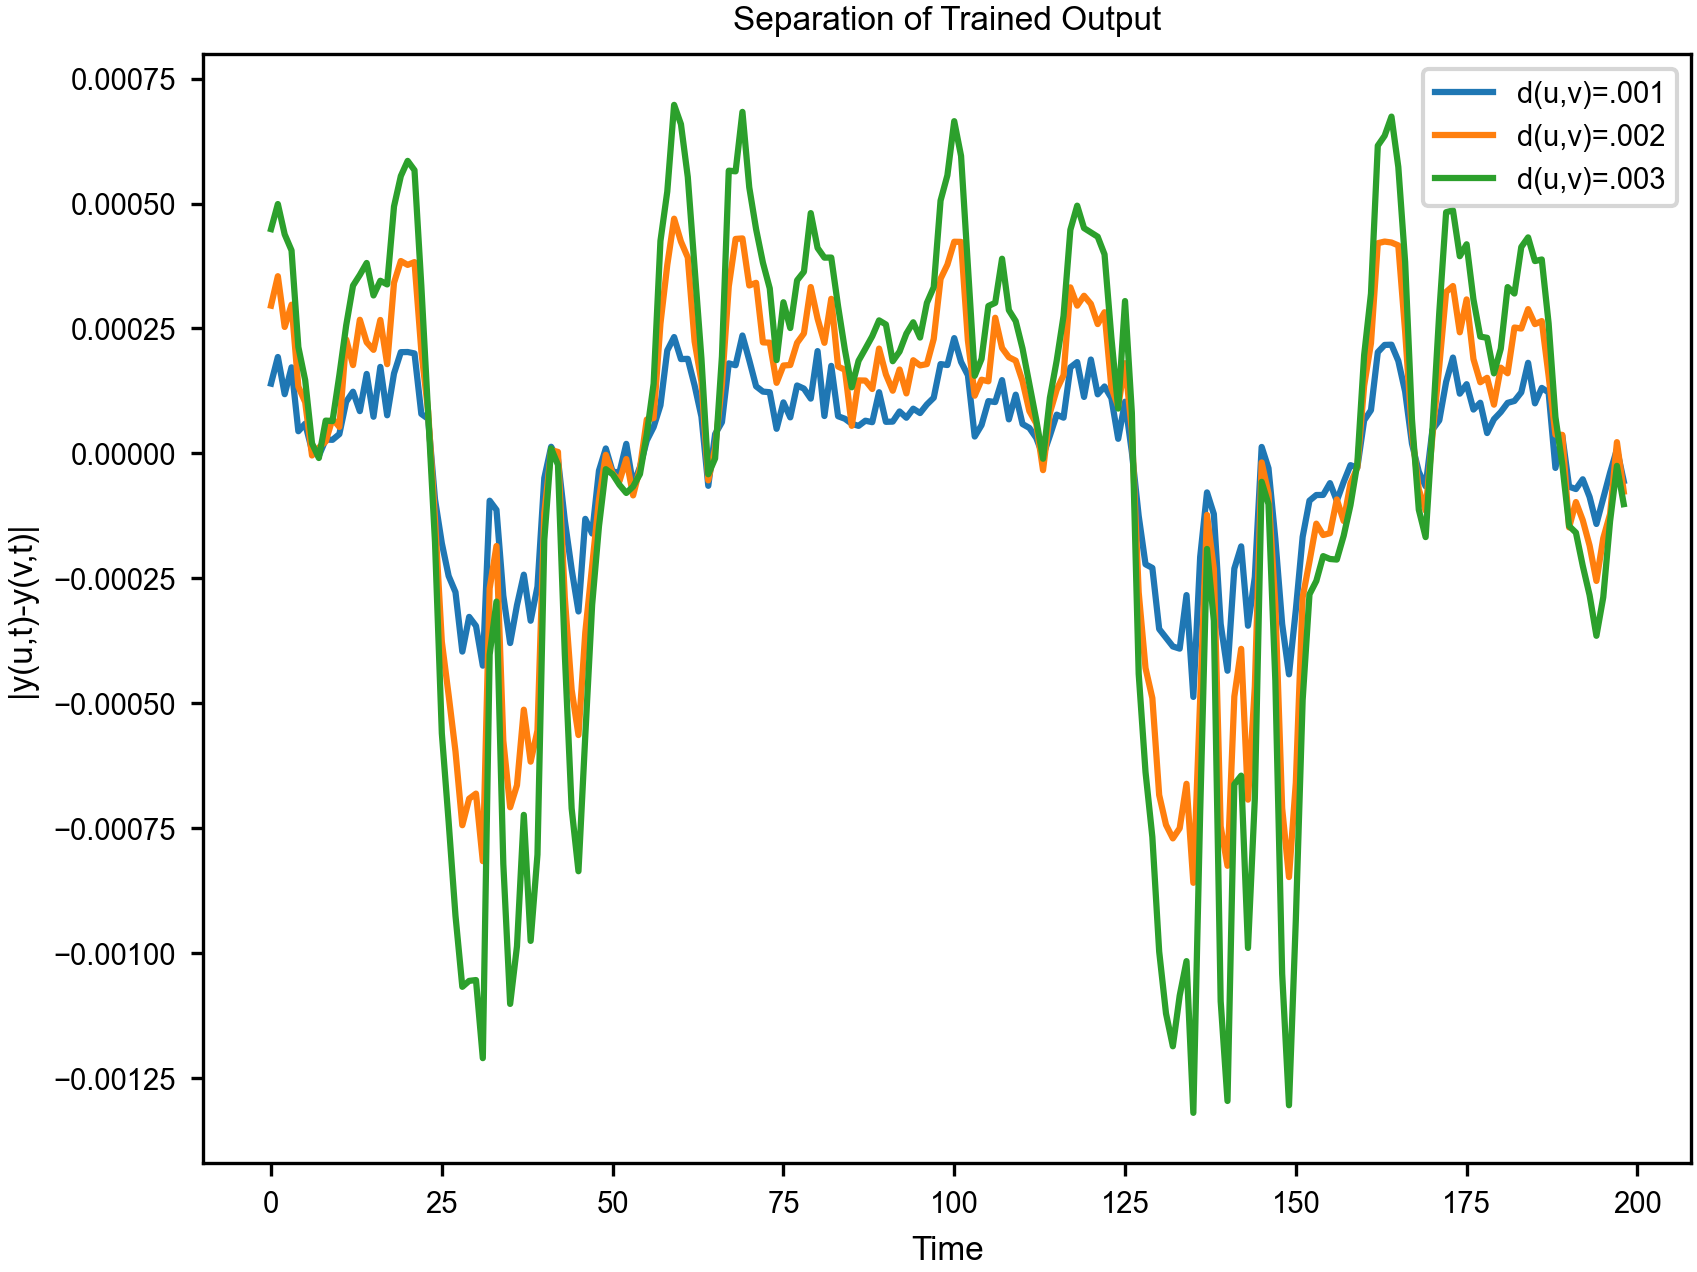

In [193]:
d001 = []
d002 = []
d003 = []
for i in range(len(y_output[0])):
    d001.append(y_output[0][i] - y_output[1][i])
    d002.append(y_output[0][i] - y_output[2][i])
    d003.append(y_output[0][i] - y_output[3][i])

time = np.linspace(0,10,len(y_output[0]))
plt.title("Separation of Trained Output")
plt.xlabel('Time')
plt.ylabel('|y(u,t)-y(v,t)|')
plt.plot(d001[:],label='d(u,v)=.001')
plt.plot(d002[:],label='d(u,v)=.002')
plt.plot(d003[:],label='d(u,v)=.003')
plt.legend()
plt.savefig('allsepration.png')

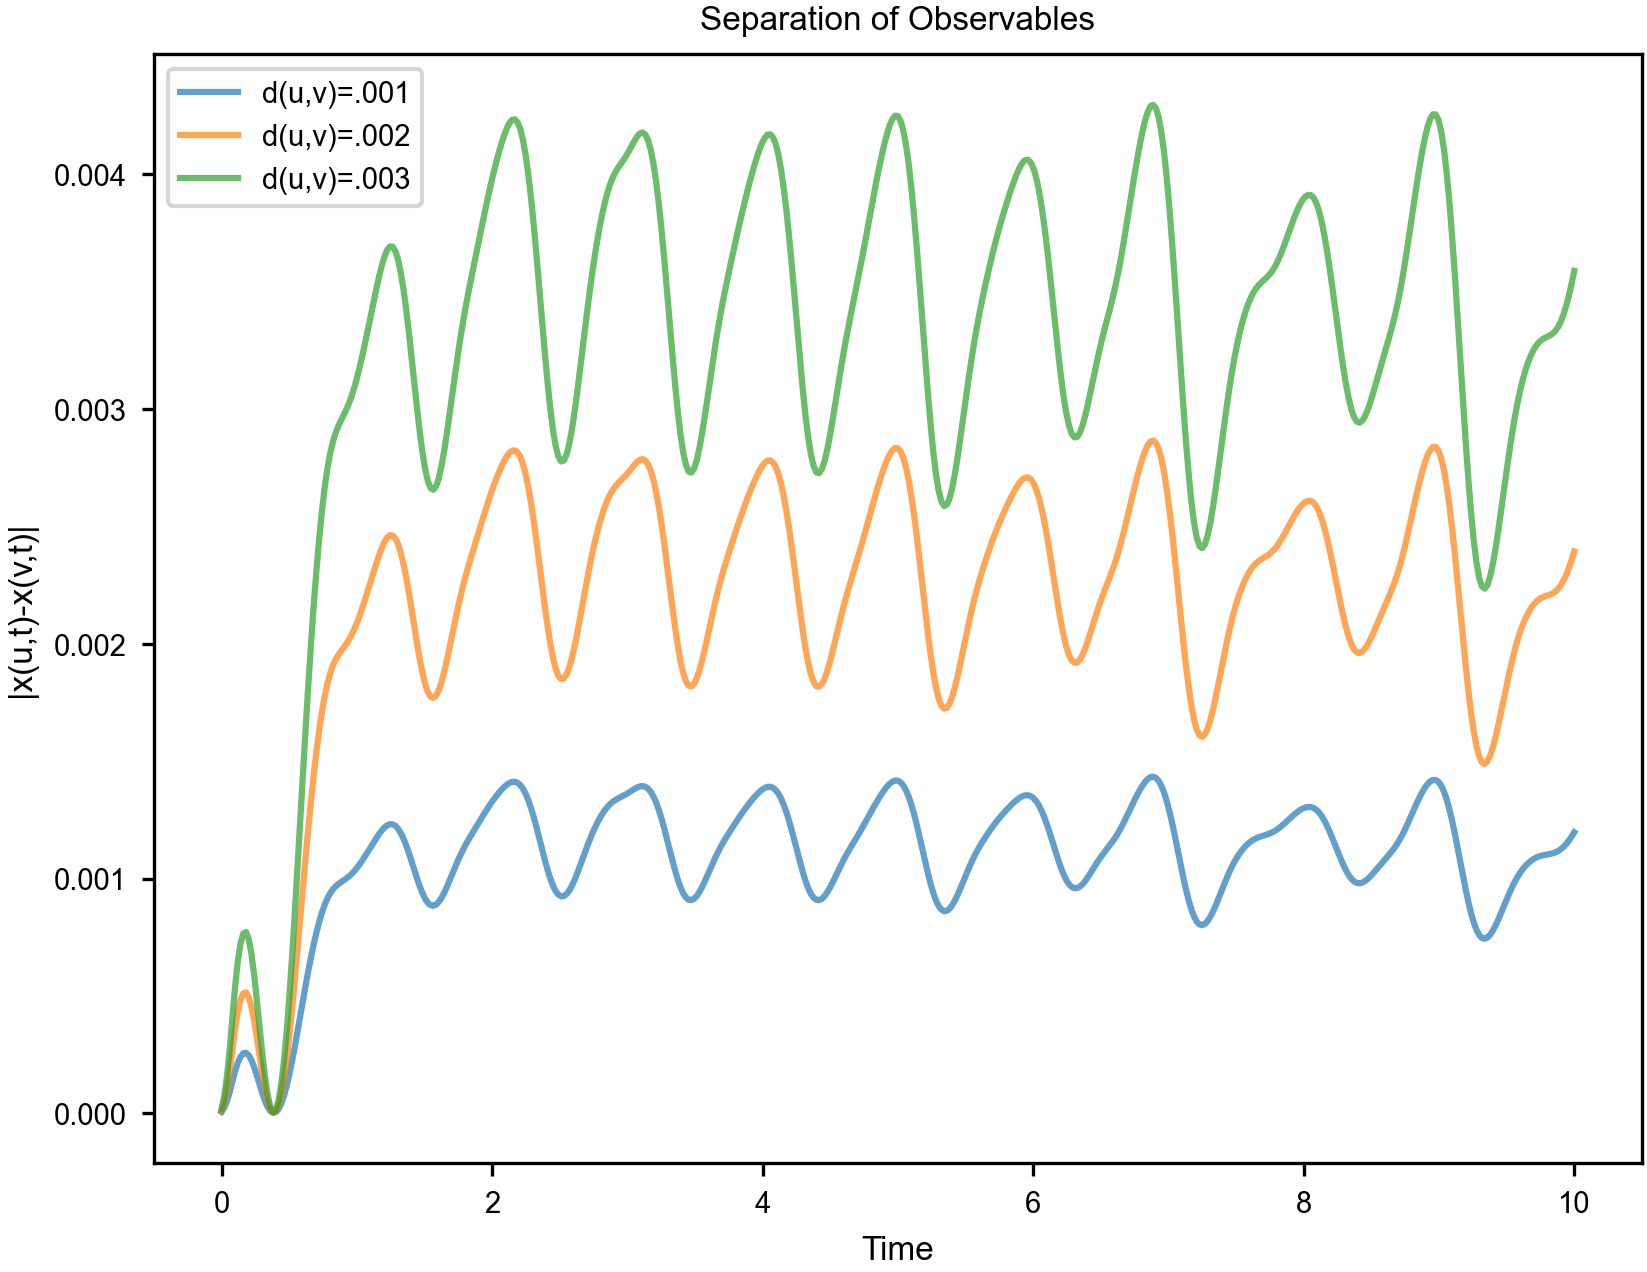

In [194]:
d001 = []
d002 = []
d003 = []
rows = X_observables[0].shape[0]
columns = X_observables[0].shape[1]
S001 = 0
S002 = 0
S003 = 0
for i in range(rows):
    for j in range(columns):
        S001 += X_observables[0][i][j] - X_observables[1][i][j]
        S002 += X_observables[0][i][j] - X_observables[2][i][j]
        S003 += X_observables[0][i][j] - X_observables[3][i][j]
    d001.append(S001)
    d002.append(S002)
    d003.append(S003)
    S001 = 0
    S002 = 0
    S003 = 0
time = np.linspace(0,10,rows)
plt.title("Separation of Observables")
plt.xlabel('Time')
plt.ylabel('|x(u,t)-x(v,t)|')
plt.plot(time[:],d001[:],label='d(u,v)=.001',alpha=0.7)
plt.plot(time[:],d002[:],label='d(u,v)=.002',alpha=0.7)
plt.plot(time[:],d003[:],label='d(u,v)=.003',alpha=0.7)
plt.legend()

In this section we demonstrate the separation and fading at the same time

In [198]:
file_names = ['reservoir1.csv', 'perturbedat100_001.csv', 'perturbedat100_002.csv', 'perturbedat100_003.csv']
y_output, X_observables = separation(file_names, Nfading = Nfading, Ntraining = Ntraining, Ntotal = Ntotal, tau =tau)
print('Done collecting data')

Done collecting data


In [200]:
X_observables[0].shape

(499, 10)

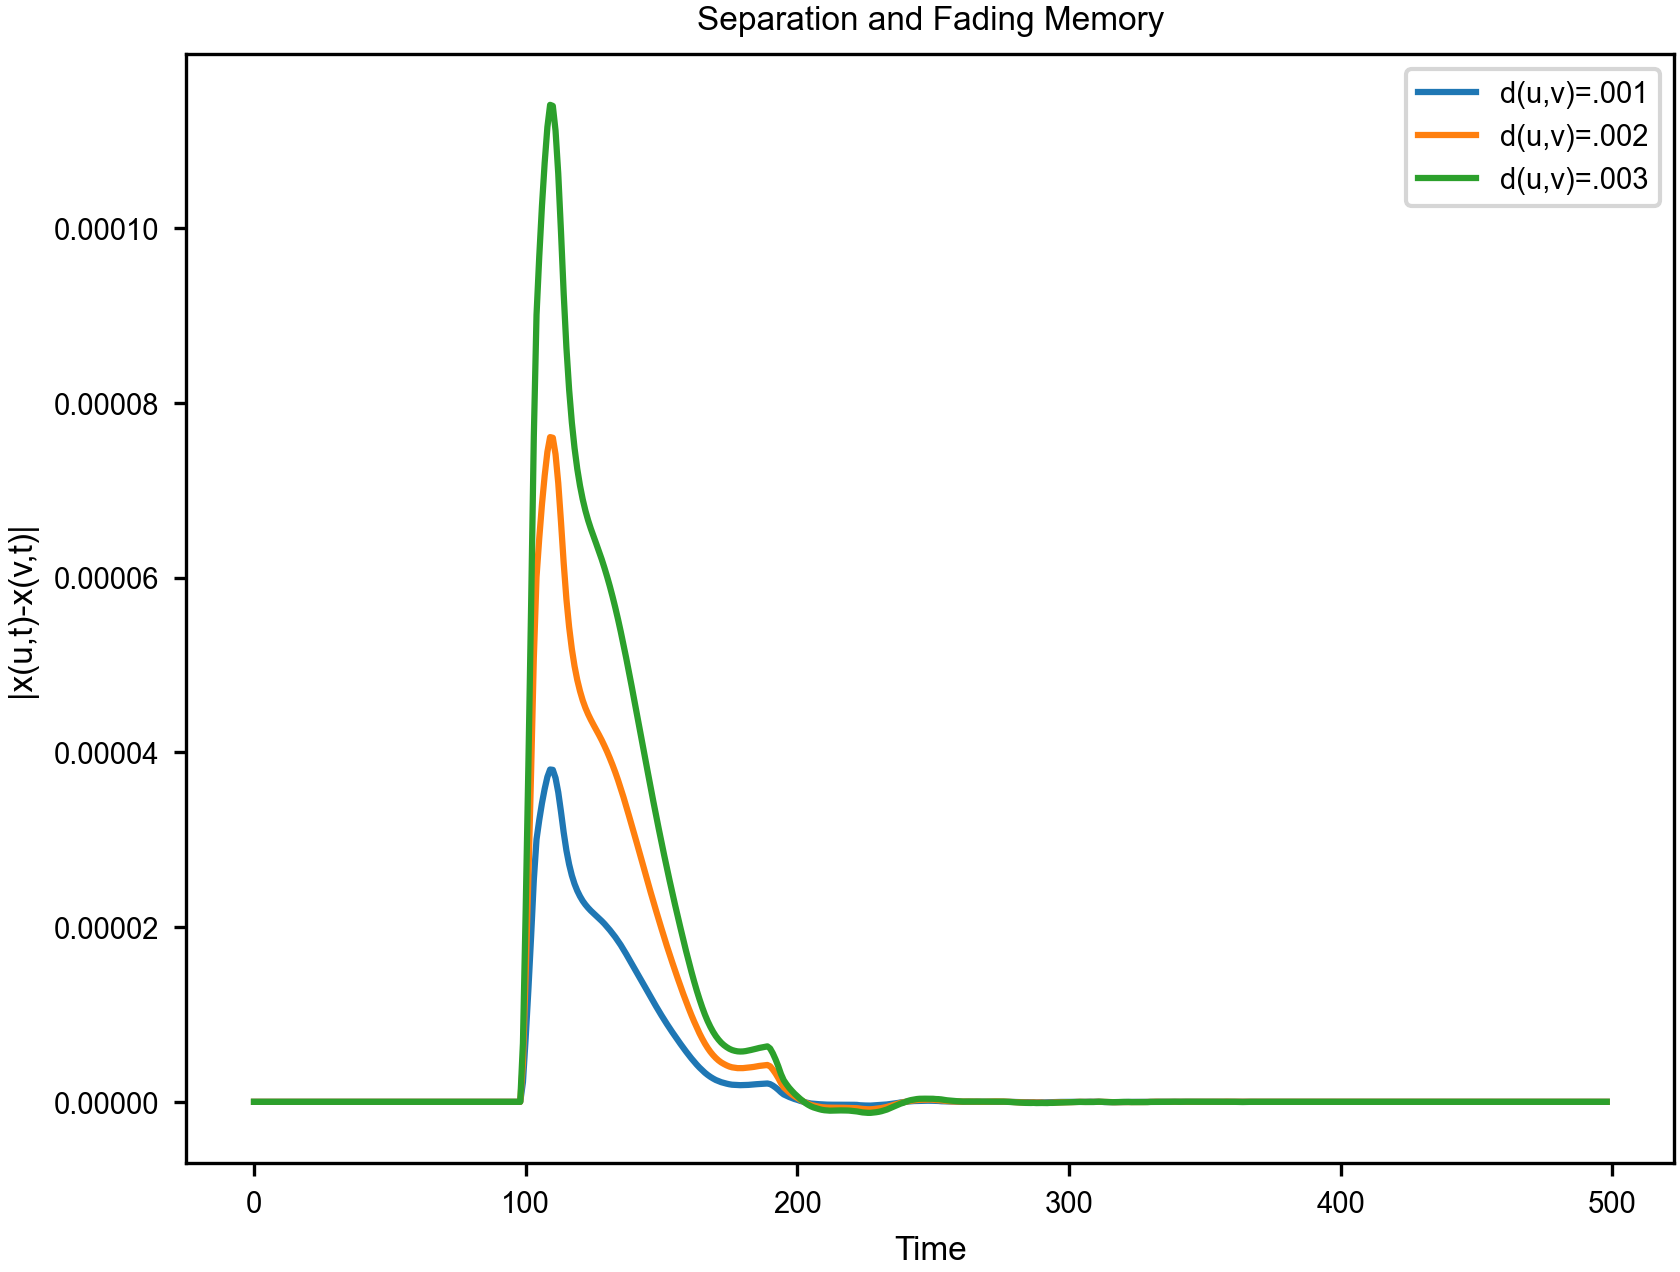

In [202]:
d001 = []
d002 = []
d003 = []
rows = X_observables[0].shape[0]
columns = X_observables[0].shape[1]
S001 = 0
S002 = 0
S003 = 0
for i in range(rows):
    for j in range(columns):
        S001 += X_observables[0][i][j] - X_observables[1][i][j]
        S002 += X_observables[0][i][j] - X_observables[2][i][j]
        S003 += X_observables[0][i][j] - X_observables[3][i][j]
    d001.append(S001)
    d002.append(S002)
    d003.append(S003)
    S001 = 0
    S002 = 0
    S003 = 0

time = np.linspace(0,10,rows)
plt.title("Separation and Fading Memory")
plt.xlabel('Time')
plt.ylabel('|x(u,t)-x(v,t)|')
plt.plot(d001[:],label='d(u,v)=.001')
plt.plot(d002[:],label='d(u,v)=.002')
plt.plot(d003[:],label='d(u,v)=.003')
plt.legend()
plt.savefig('PerturbedandSeparation.png')

Polynomial Algebra: The idea here is that we use two different reservoirs to train the Mackey Glass. We then add and multiply their output together. We then show that there exists a third reservoir that can approximate that well.

In [205]:
def addition_multiplication(file_names, Nfading = 10, Ntraining = 290, Ntotal = 500, tau = 1, N=10):
    task = mackey_glass(Npoints=Ntotal)
    Ntesting = Ntotal - Nfading - Ntraining
    K = Ntotal - tau
    y_output = []
    NRMSE = []
    for file_name in file_names:
        df = pd.read_csv(file_name)
        X = extract_delayed_single_column(df, 'PQ0', N=N, repeat_steps=1)
        X_features = X[0:K]
        X_train = X_features[Nfading : Nfading + Ntraining, :]
        X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
        y_target = task[tau : K + tau]
        y_fading = y_target[:Nfading]
        y_train = y_target[Nfading : Nfading + Ntraining]
        y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
        W = fitting_function(X_train, y_train)
        y_prediction = predict(X_test, W)
        error = nrmse(y_prediction, y_test)
        NRMSE.append(error)
        y_train_prediction = predict(X_train, W)


        y_all_prediction = np.concatenate((np.array(y_fading), np.array(y_train_prediction), np.array(y_prediction))) # concatenate training and target
        y_output.append(y_all_prediction)

    added = [a + b for a, b in zip(y_output[0], y_output[1])]
    multiplied = [a * b for a, b in zip(y_output[0], y_output[1])]
 
    return NRMSE, added, multiplied, y_output, y_target

In [207]:
file_names =  ['reservoir1.csv','reservoir2.csv']
NRMSE, added, multiplied, y_output, y_target = addition_multiplication(file_names, Nfading = 10, Ntraining = 290, Ntotal = 500, tau = 1, N=10)

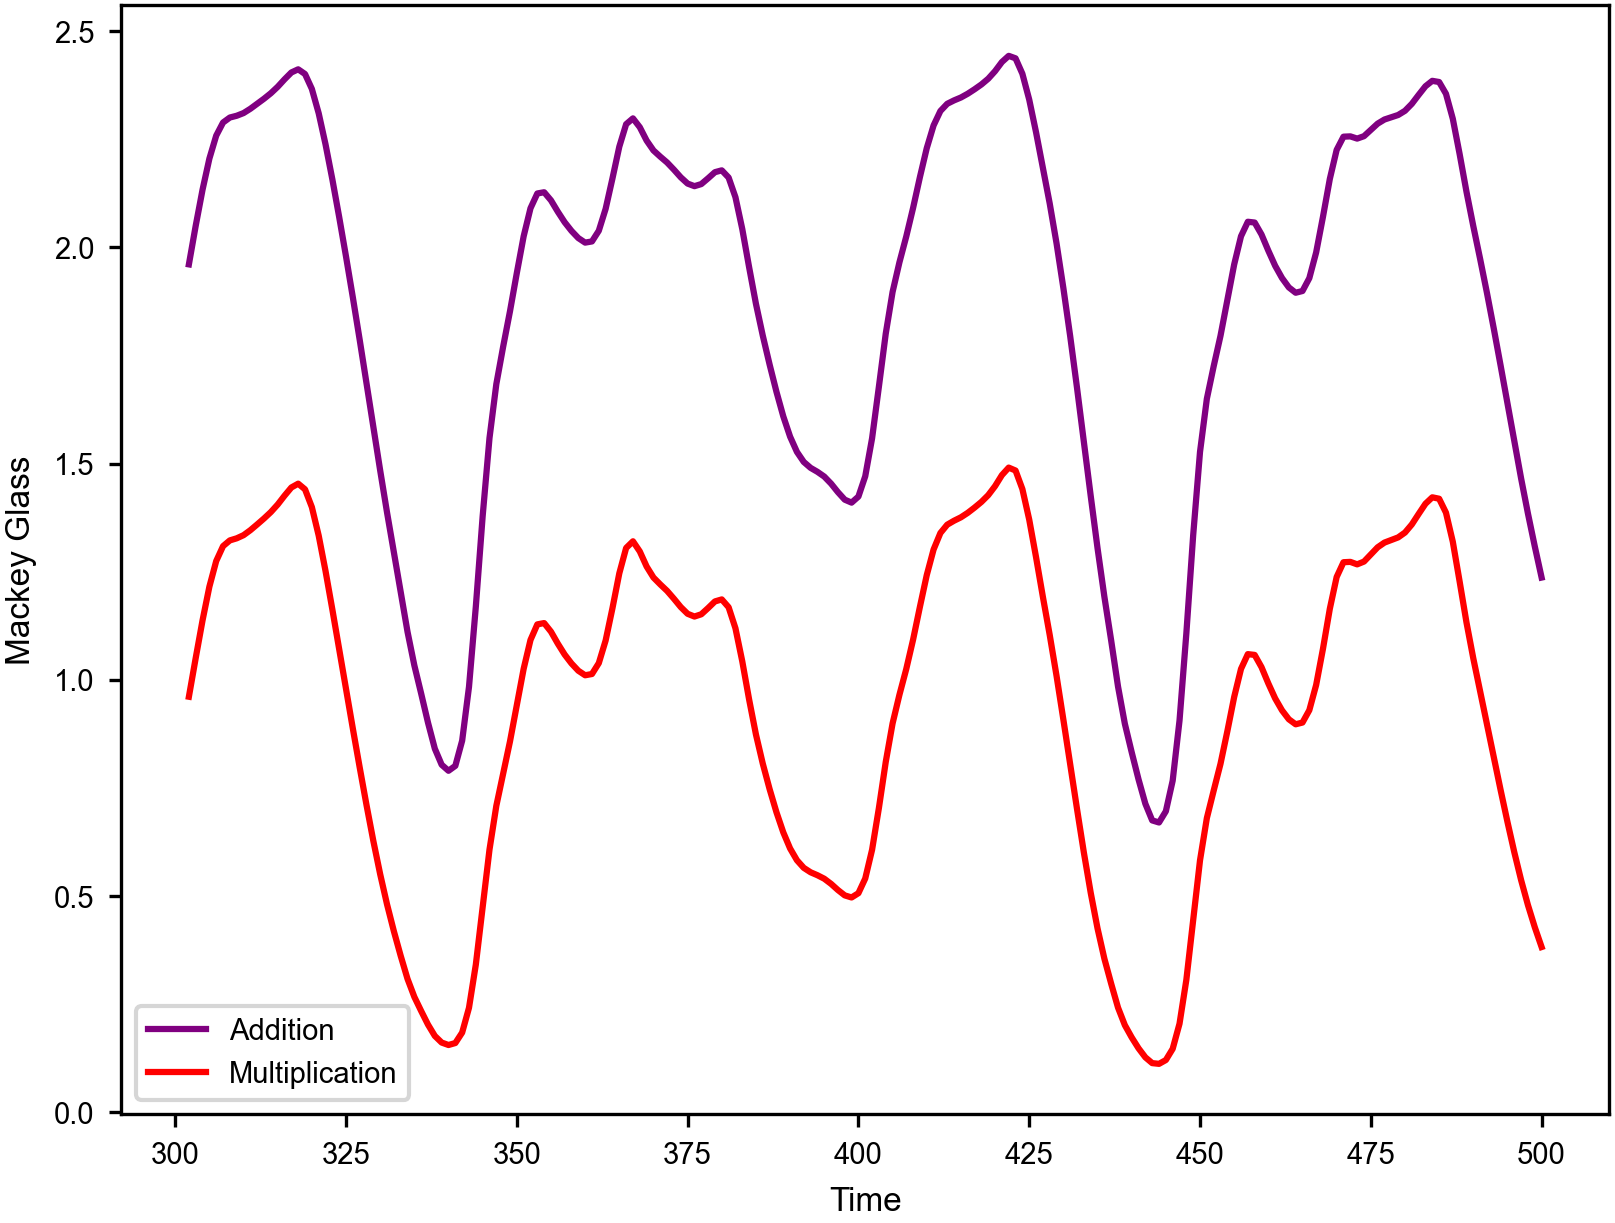

In [209]:
#plt.plot(y_output[0],label='Reservoir 1')
#plt.plot(y_output[1],label='Reservoir 2')
#plt.plot(y_target,label='Target')
x = np.linspace(1, 500, 500)
plt.plot(x[301:],added[300:],label='Addition',color='Purple')
plt.plot(x[301:],multiplied[300:],label='Multiplication',color='Red')
plt.xlabel('Time')
plt.ylabel('Mackey Glass')
plt.legend()
plt.savefig('addmul.png')

In [215]:
len(y_test)

199

error:  0.01838868796308824


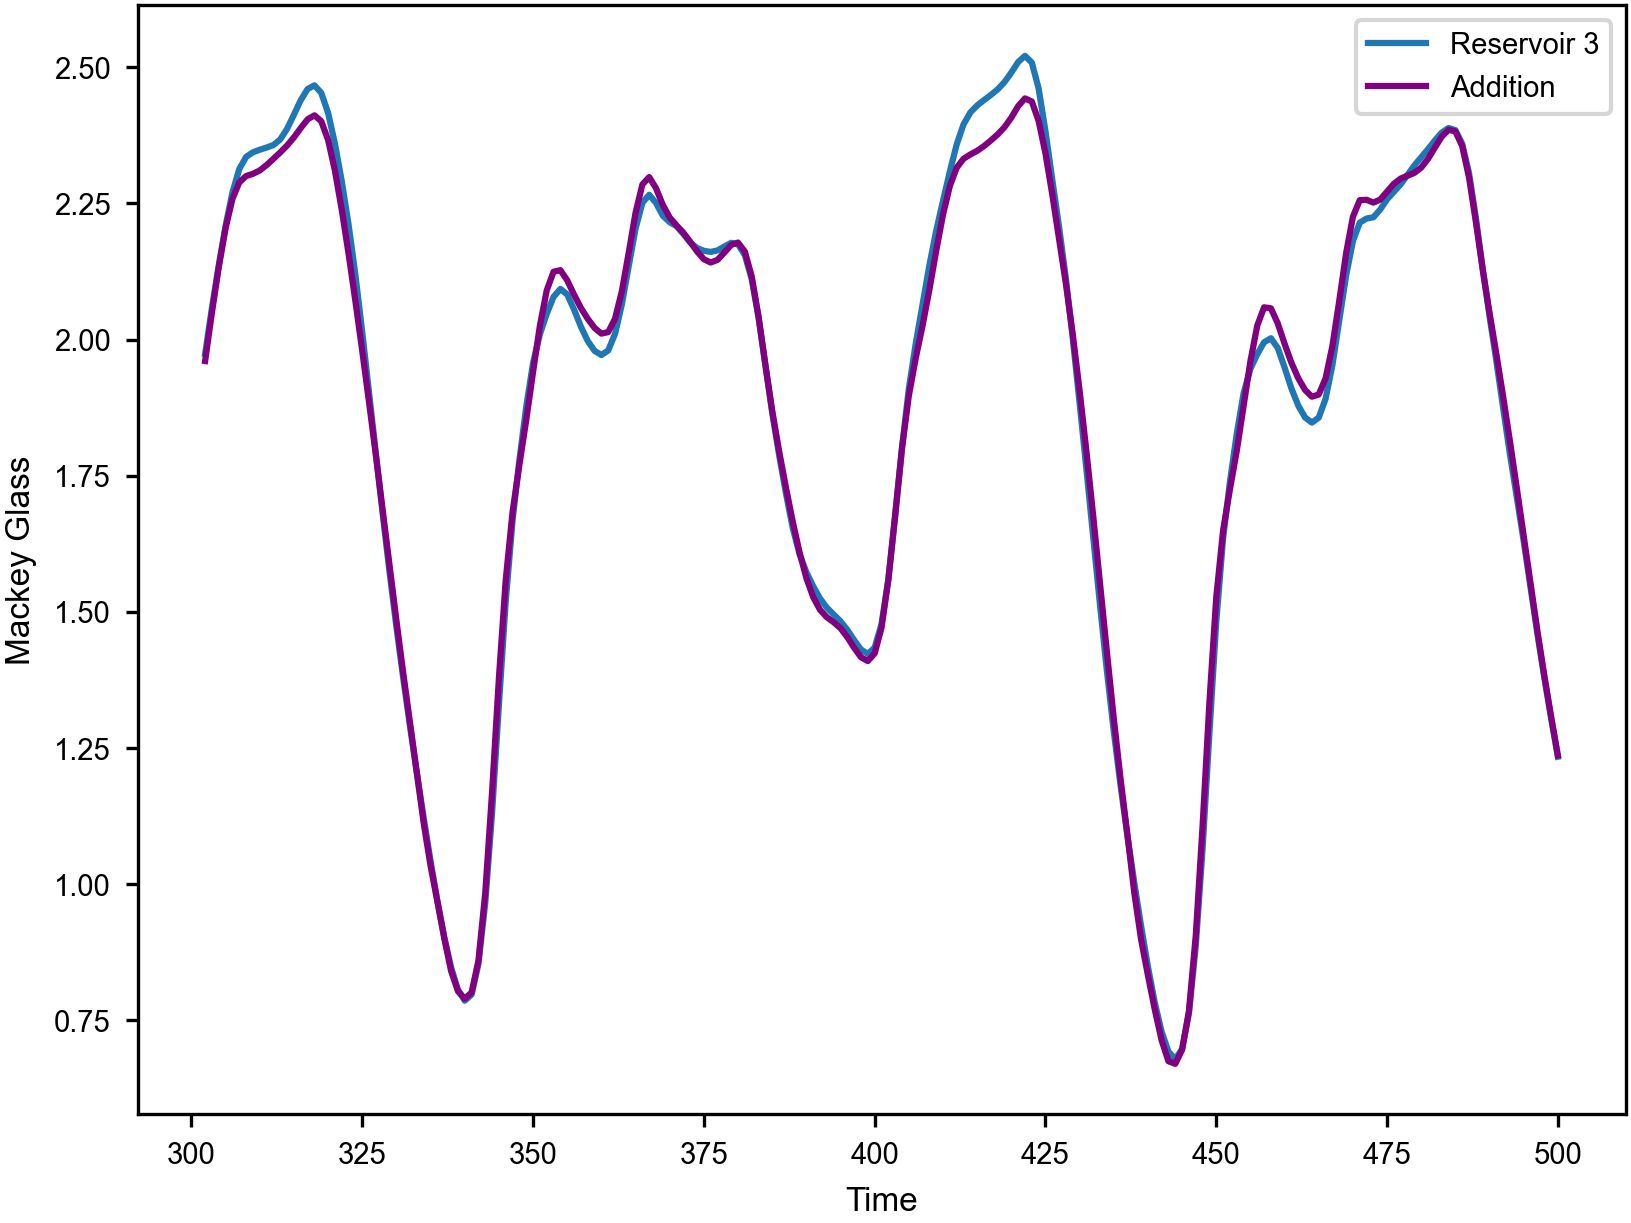

In [217]:
df = pd.read_csv('reservoir3_rep2.csv') # reservoir 3 doing great job
X = extract_delayed_single_column(df, 'PQ0', N=20, repeat_steps=2)
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
y_target = added
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print('error: ', error)
plt.plot(x[301:],y_prediction, label='Reservoir 3')
plt.plot(x[301:],y_test, label='Addition', color='purple')
plt.xlabel('Time')
plt.ylabel('Mackey Glass')
plt.legend()
plt.savefig('predadd.png')

error:  0.028314995258646055


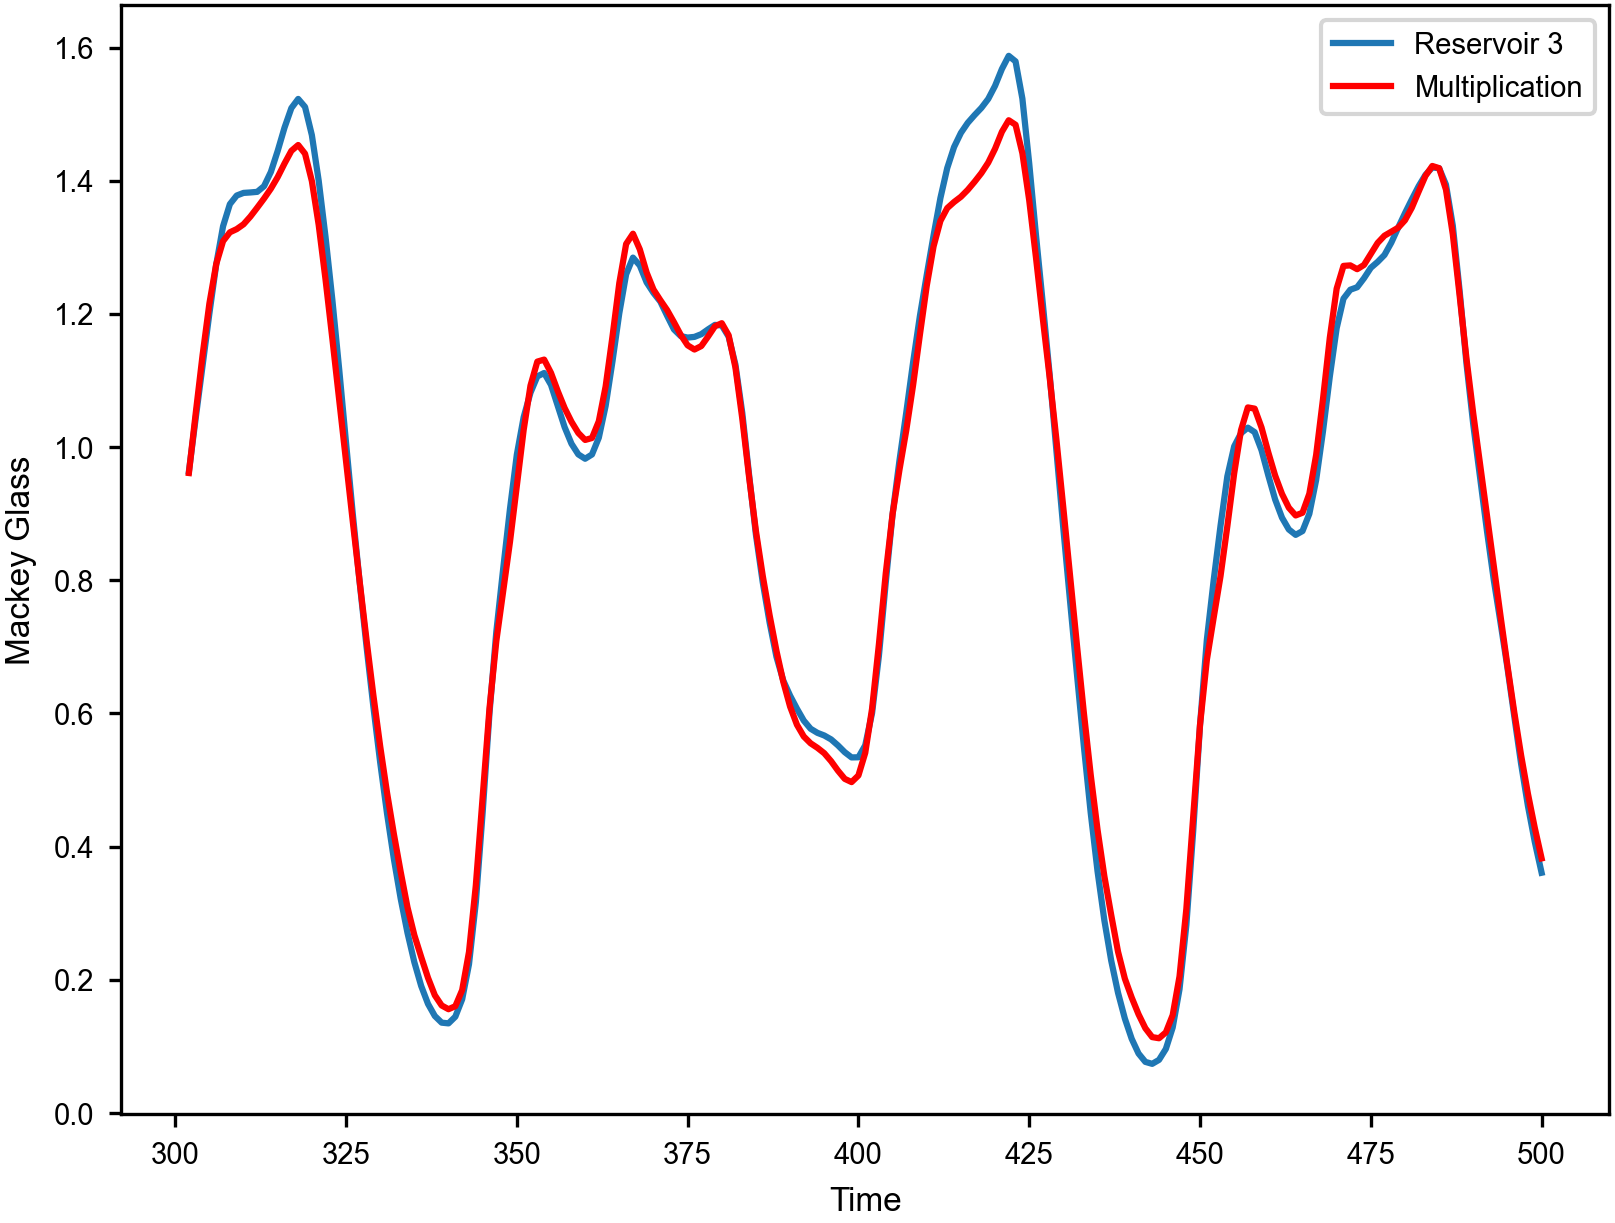

In [219]:
df = pd.read_csv('reservoir3_rep2.csv') # reservoir 3 doing great job
X = extract_delayed_single_column(df, 'PQ0', N=20, repeat_steps=2)
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
y_target = multiplied
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print('error: ', error)
plt.plot(x[301:],y_prediction, label='Reservoir 3')
plt.plot(x[301:],y_test, label='Multiplication',color='red')
plt.xlabel('Time')
plt.ylabel('Mackey Glass')
plt.legend()
plt.savefig('predmul.png')

Polynomial Regression: we show that by adding multinomial regression modes $\langle P \rangle\langle Q \rangle$, $\langle P \rangle\langle P \rangle$... We can saturate the error. 

In [221]:
df = pd.read_csv('MG_omega0.1_rep10.csv') # reservoir 3 doing great job
X = extract_delayed_p_or_q_single_column(df, 'PQ-10', N=10, repeat_steps=10)
X = add_polynomial_features(X,nodes=10)
X.shape

(1000, 50)

In [222]:
nodes = [10,20,30,40,50]
nodes = [i+1 for i in range(50)]
task = np.array(mackey_glass(Npoints=1000))

In [225]:
NRMSE = []
Nfading = 100
Ntraining = 600
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau=1 # 10 delay 
K = Ntotal-tau
for node in nodes:
    X_features = X[0:K]
    X_train = X_features[Nfading : Nfading + Ntraining, :node]
    X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:node]
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    W = fitting_function(X_train, y_train)
    y_prediction = predict(X_test, W)
    error = nrmse(y_prediction, y_test)
    NRMSE.append(error)
    print('error: ', error)

error:  0.2503274464984751
error:  0.18139853879529375
error:  0.16017804241820366
error:  0.12534774397838852
error:  0.10263796548450685
error:  0.07823087827980711
error:  0.061777008743702524
error:  0.05097184929933453
error:  0.045205703955275525
error:  0.04221859924587122
error:  0.0407158379057661
error:  0.040332736605362296
error:  0.04035477125418597
error:  0.03852874864820067
error:  0.03829933712646179
error:  0.03665315793776817
error:  0.03411806245300384
error:  0.033253019758493006
error:  0.032769857797106755
error:  0.03251199195631947
error:  0.032524232947371806
error:  0.030642233358010227
error:  0.02542758755200234
error:  0.025490611194099837
error:  0.02493898128184637
error:  0.021174486974636503
error:  0.016767038571468905
error:  0.013996416264890506
error:  0.01248623301444552
error:  0.01185498496470351
error:  0.011694917515189262
error:  0.011695932523029482
error:  0.011721654367669167
error:  0.011750066501955767
error:  0.011695173449028986
error:

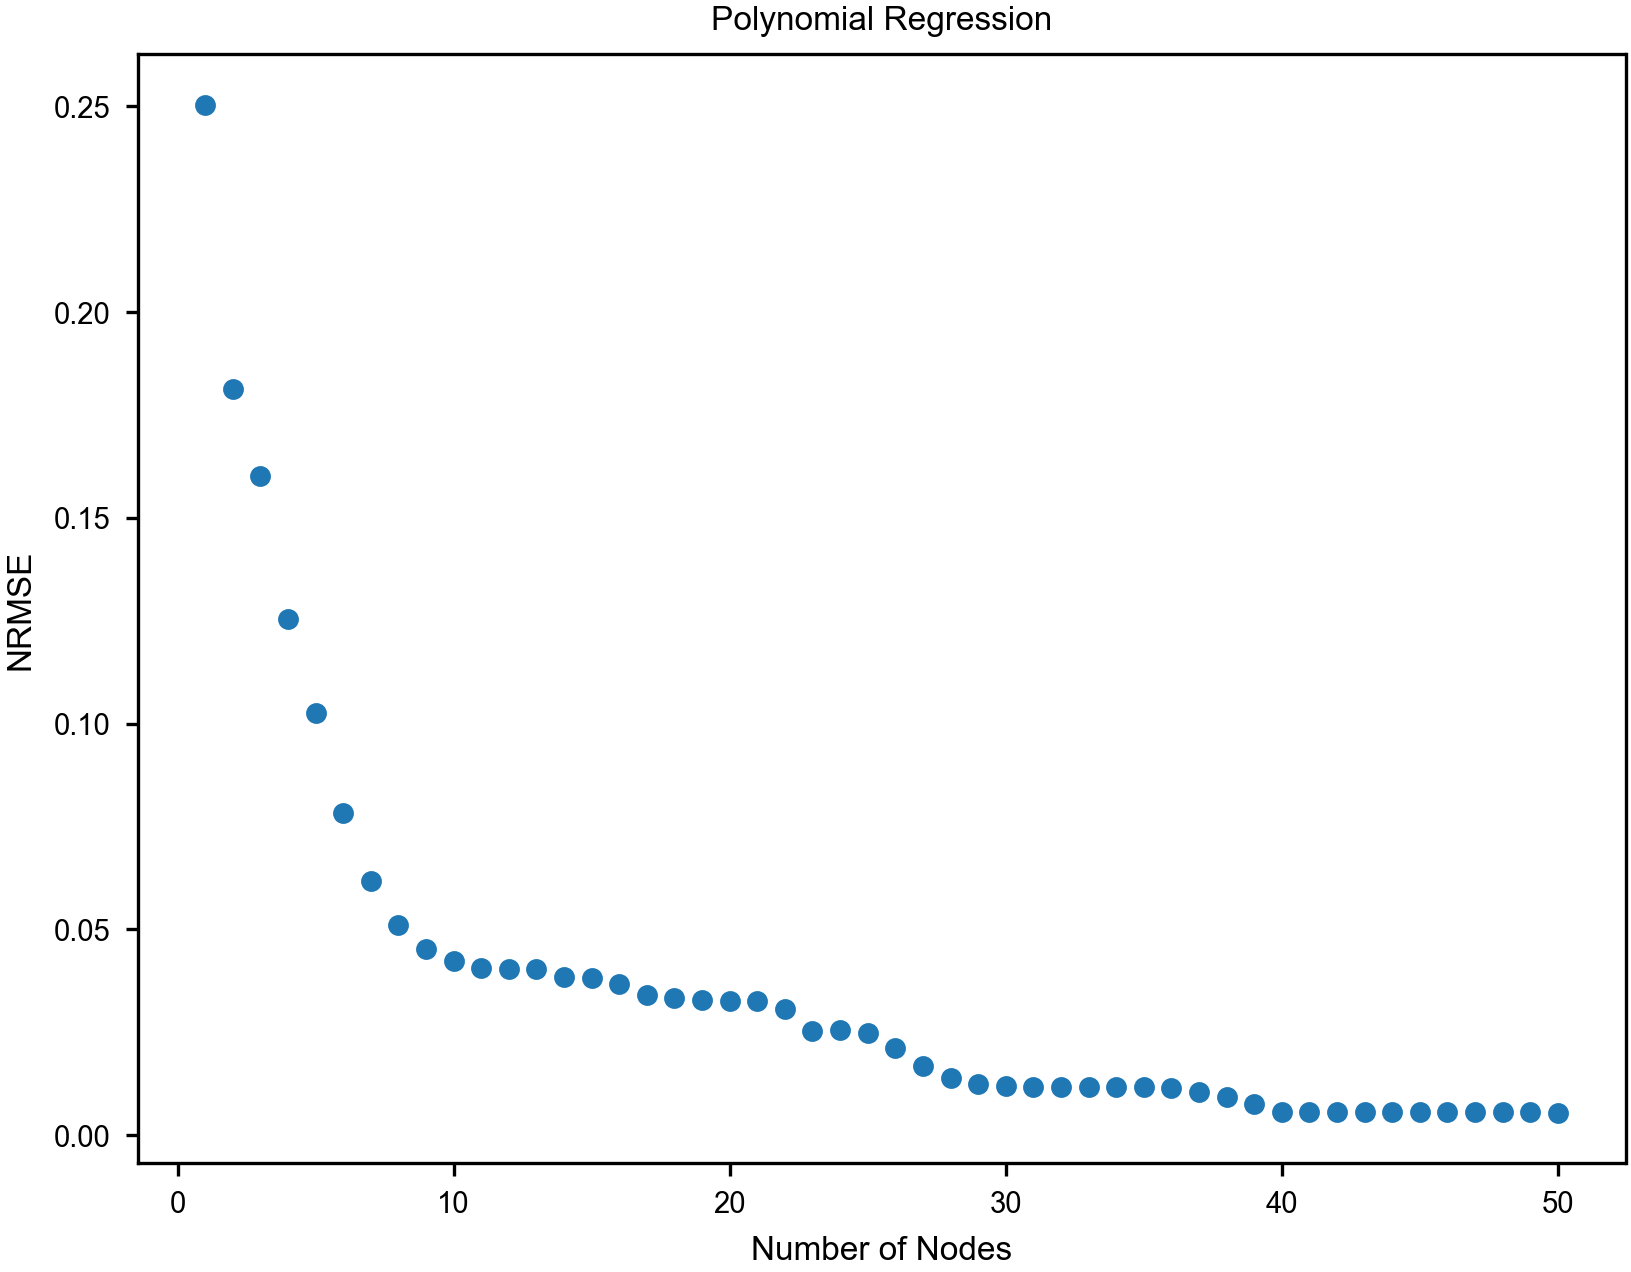

In [227]:
plt.scatter(nodes, NRMSE)
plt.xlabel('Number of Nodes')
plt.ylabel('NRMSE')
plt.title('Polynomial Regression')
plt.savefig('polyreg.png')